# 07 — Post-method train/test splits

Split subjects after TEMPTED has been fit to the full cohort.

The split tests how well the learned TEMPTED subject components predict country in held-out subjects. It does not test a fully held-out decomposition pipeline because TEMPTED was fit before the split.


In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

N_SPLITS = 100
TEST_SIZE = .20
SEED = 2026

root = Path(".") if Path("data").exists() else Path("..")
prep = sorted((root / "data" / "preprocessing").iterdir())[-1]
t_dir = sorted((root / "data" / "tempted").iterdir())[-1]
output = root / "data" / "train_test" / datetime.now().strftime("%Y%m%d_%H%M%S")
figures = output / "figures"
figures.mkdir(parents=True)

# load TEMPTED subject scores and country
metadata = pd.read_csv(
    prep / "metadata.csv",
    dtype={"subject_id": str},
)
tempted = pd.read_csv(
    t_dir / "subject_scores.csv",
    dtype={"subject_id": str},
)

country = metadata[
    ["subject_id", "country"]
].drop_duplicates("subject_id")

tempted = tempted.merge(
    country,
    on="subject_id",
)

countries = ["FIN", "EST", "RUS"]
colors = {
    "FIN": "green",
    "EST": "blue",
    "RUS": "red",
}

tempted = tempted[
    tempted["country"].isin(countries)
].reset_index(drop=True)

t_dims = [
    c for c in tempted
    if c.startswith("component_")
]


In [2]:
# TEMPTED subjects used for the repeated splits

subjects = tempted[["subject_id", "country"]].copy()

print(
    len(subjects),
    "subjects |",
    subjects["country"].value_counts().to_dict(),
)


209 subjects | {'EST': 71, 'FIN': 69, 'RUS': 69}


## Repeated subject-level splits

Use 100 stratified 80/20 subject splits. The classifier is fit only after each split. Balanced accuracy is the main score because it gives each country equal weight.


In [3]:
# make repeated stratified subject splits

splitter = StratifiedShuffleSplit(
    n_splits=N_SPLITS,
    test_size=TEST_SIZE,
    random_state=SEED,
)

scores = []
predictions = []
first_split = None

for split, (train_index, test_index) in enumerate(
    splitter.split(subjects, subjects["country"]),
    start=1,
):
    if split == 1:
        first_split = (train_index, test_index)

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000),
    )

    x_train = tempted.iloc[train_index][t_dims]
    y_train = tempted.iloc[train_index]["country"]
    x_test = tempted.iloc[test_index][t_dims]
    y_test = tempted.iloc[test_index]["country"]

    model.fit(x_train, y_train)

    train_prediction = model.predict(x_train)
    test_prediction = model.predict(x_test)

    scores.append([
        "TEMPTED",
        split,
        "train",
        accuracy_score(y_train, train_prediction),
        balanced_accuracy_score(y_train, train_prediction),
    ])

    scores.append([
        "TEMPTED",
        split,
        "test",
        accuracy_score(y_test, test_prediction),
        balanced_accuracy_score(y_test, test_prediction),
    ])

    for subject_id, actual, predicted in zip(
        tempted.iloc[test_index]["subject_id"],
        y_test,
        test_prediction,
    ):
        predictions.append([
            "TEMPTED",
            split,
            subject_id,
            actual,
            predicted,
        ])

scores = pd.DataFrame(
    scores,
    columns=[
        "method",
        "split",
        "set",
        "accuracy",
        "balanced_accuracy",
    ],
)

predictions = pd.DataFrame(
    predictions,
    columns=[
        "method",
        "split",
        "subject_id",
        "actual_country",
        "predicted_country",
    ],
)

scores.to_csv(
    output / "split_scores.csv",
    index=False,
)
predictions.to_csv(
    output / "test_predictions.csv",
    index=False,
)

print("Saved:", output)

scores[
    scores["set"] == "test"
][["accuracy", "balanced_accuracy"]].mean()


Saved: ../data/train_test/20260816_182146


accuracy             0.521905
balanced_accuracy    0.521905
dtype: float64

In [4]:
# save a figure

def save(name):
    plt.tight_layout()
    plt.savefig(figures / name, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


## Split visualizations

The first plot shows the first train/test split in TEMPTED component space. The score plot summarizes variability across all 100 held-out splits, and the confusion matrix summarizes the pooled held-out country predictions.


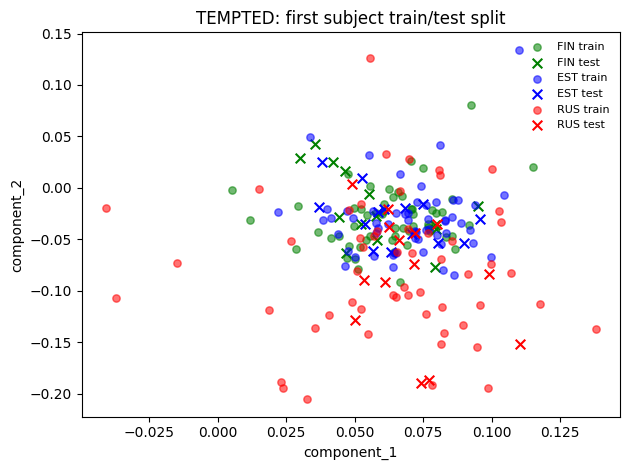

In [5]:
# show the first split in TEMPTED component space

train_index, test_index = first_split

for country in countries:
    train = tempted.iloc[train_index]
    test = tempted.iloc[test_index]

    train = train[train["country"] == country]
    test = test[test["country"] == country]

    plt.scatter(
        train[t_dims[0]],
        train[t_dims[1]],
        s=28,
        alpha=.55,
        color=colors[country],
        label=f"{country} train",
    )

    plt.scatter(
        test[t_dims[0]],
        test[t_dims[1]],
        s=48,
        marker="x",
        color=colors[country],
        label=f"{country} test",
    )

plt.xlabel(t_dims[0])
plt.ylabel(t_dims[1])
plt.legend(frameon=False, fontsize=8)
plt.title("TEMPTED: first subject train/test split")
save("tempted_first_split.png")


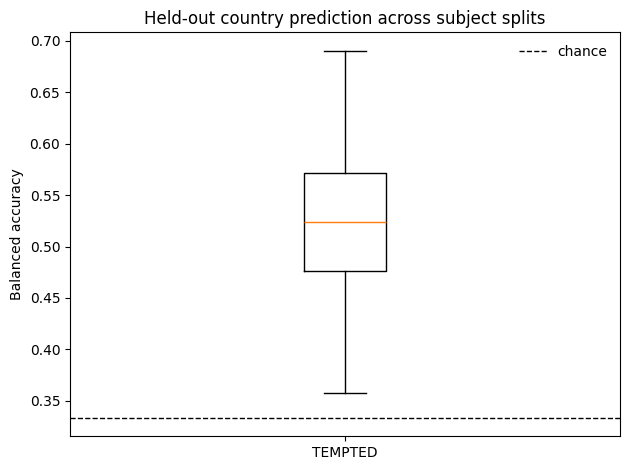

In [6]:
# held-out balanced accuracy across splits

test_scores = scores[
    scores["set"] == "test"
]["balanced_accuracy"]

plt.boxplot(
    [test_scores],
    tick_labels=["TEMPTED"],
)

plt.axhline(
    1 / len(countries),
    color="black",
    linestyle="--",
    linewidth=1,
    label="chance",
)

plt.ylabel("Balanced accuracy")
plt.title("Held-out country prediction across subject splits")
plt.legend(frameon=False)
save("test_balanced_accuracy.png")


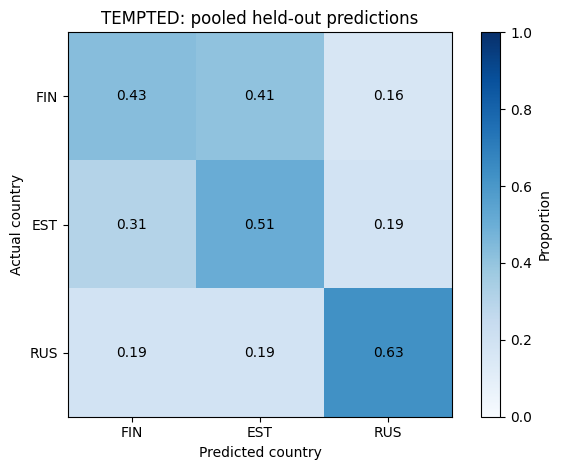

In [7]:
# pooled held-out confusion matrix

matrix = confusion_matrix(
    predictions["actual_country"],
    predictions["predicted_country"],
    labels=countries,
    normalize="true",
)

plt.imshow(
    matrix,
    vmin=0,
    vmax=1,
    cmap="Blues",
)

plt.colorbar(label="Proportion")
plt.xticks(range(len(countries)), countries)
plt.yticks(range(len(countries)), countries)
plt.xlabel("Predicted country")
plt.ylabel("Actual country")
plt.title("TEMPTED: pooled held-out predictions")

for i in range(len(countries)):
    for j in range(len(countries)):
        plt.text(
            j,
            i,
            f"{matrix[i, j]:.2f}",
            ha="center",
            va="center",
        )

save("tempted_test_confusion.png")
